In [41]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix

In [42]:
df = pd.read_csv('tested.csv')

#select 2 features age and fare, the target feature is survived
#also handle the missing values by dropping all the nulls
df = df[['Age','Fare','Survived']].dropna()
df

,Age,Fare,Survived
0,34.5,7.8292,0
1,47.0,7.0000,1
2,62.0,9.6875,0
3,27.0,8.6625,0
4,22.0,12.2875,1
...,...,...,...
409,3.0,13.7750,1
411,37.0,90.0000,1
412,28.0,7.7750,1
414,39.0,108.9000,1


In [43]:
# extract features and target
X = df[['Age','Fare']].values #.values converts all the data into a numpy array
Y = df['Survived'].values

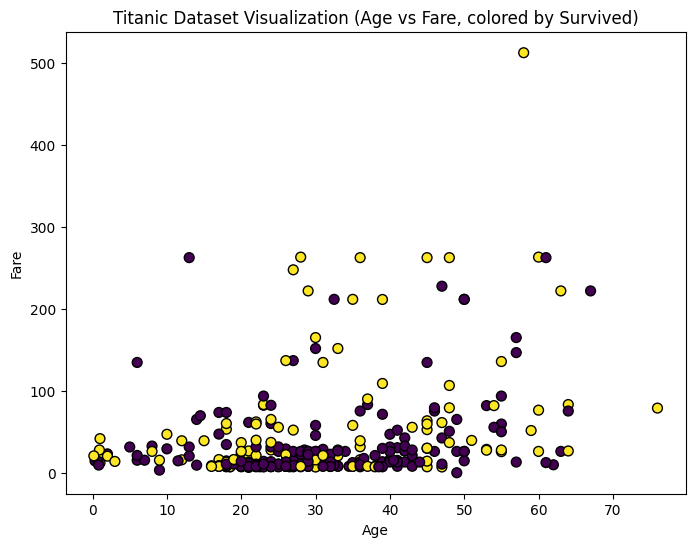

In [44]:
#Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='viridis', edgecolor='k', s=50)
plt.title('Titanic Dataset Visualization (Age vs Fare, colored by Survived)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

In [45]:
# splitting the test and training data
X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.2 , random_state=42)
# train the knn classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,Y_train)
#make predictions on the test set
Y_pred = knn.predict(X_test)

Accuracy:0.67
Precision:0.50
Recall:0.45


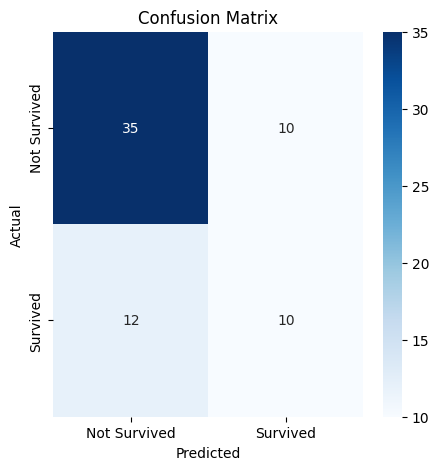

In [46]:
# evaluating the model
accuracy = accuracy_score(Y_test,Y_pred)
precision = precision_score(Y_test,Y_pred)
recall = recall_score(Y_test,Y_pred)
conf_matrix = confusion_matrix(Y_test,Y_pred)
#print the metrices
print(f'Accuracy:{accuracy:.2f}')
print(f'Precision:{precision:.2f}')
print(f'Recall:{recall:.2f}')
# visualize the confusin matrix
plt.figure(figsize=(5,5))
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues',xticklabels=['Not Survived','Survived'],yticklabels=['Not Survived','Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()